# PHẦN I: PIPELINE HUẤN LUYỆN & ĐÁNH GIÁ CHÍNH
Khu vực chứa pipeline thực thi chuẩn: nạp cấu hình, tiền xử lý, huấn luyện 4.000 steps và đánh giá hiệu năng mô hình.

## 1. Thiết lập Môi trường & Dependencies
Cài đặt các gói thư viện cần thiết phục vụ việc huấn luyện VietOCR và tính toán sai số khoảng cách ký tự (CER/WER).

In [7]:
# [Phần I - Cell 1] Cài đặt VietOCR không kèm phụ thuộc thừa (--no-deps) và các gói lõi
!pip install -q git+https://github.com/pbcquoc/vietocr.git --no-deps
!pip install -q einops prefetch_generator editdistance gdown pyyaml pillow torchvision lmdb

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 5.8 MB/s eta 0:00:00:00:01


## 2. Cấu hình Đường dẫn Động (Low Coupling Config)
Quản lý tập trung các đường dẫn đầu vào/đầu ra. Mã nguồn tự động nhận biết môi trường thực thi (Kaggle hoặc Local), không hardcode đường dẫn tuyệt đối.

In [2]:
# [Phần I - Cell 2] Khởi tạo cấu hình đường dẫn động
import os
from pathlib import Path

IS_KAGGLE = Path('/kaggle').exists()

OUTPUT_DIR = Path('/kaggle/working') if IS_KAGGLE else Path('./output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if IS_KAGGLE:
    RAW_DATA_IMG_DIR = Path('/kaggle/input/datasets/trnchihong/viethandocr-data')
    RAW_SPLIT_DIR = Path('/kaggle/input/datasets/danhngnnguyn/results-updated/results')
else:
    RAW_DATA_IMG_DIR = Path('./data/viethandocr-data')
    RAW_SPLIT_DIR = Path('./data/results')

CONFIG_PATHS = {
    'raw_img_dir': RAW_DATA_IMG_DIR,
    'raw_train_txt': RAW_SPLIT_DIR / 'train_line.txt',
    'raw_val_txt': RAW_SPLIT_DIR / 'val_line.txt',
    'raw_test_txt': RAW_SPLIT_DIR / 'test_line.txt',
    # File nhãn sạch sau khi tiền xử lý và lọc truncation
    'clean_train_annotation': OUTPUT_DIR / 'clean_train_line.txt',
    'clean_val_annotation': OUTPUT_DIR / 'clean_val_line.txt',
    'checkpoint_dir': OUTPUT_DIR / 'checkpoints',
}

CONFIG_PATHS['checkpoint_dir'].mkdir(parents=True, exist_ok=True)
print("=== ĐÃ THIẾT LẬP XONG CẤU HÌNH ĐƯỜNG DẪN ===")
print(f"Ảnh gốc:    {CONFIG_PATHS['raw_img_dir']}")
print(f"Train gốc:  {CONFIG_PATHS['raw_train_txt']}")
print(f"Val gốc:    {CONFIG_PATHS['raw_val_txt']}")
print(f"Thư mục ra: {OUTPUT_DIR}")

=== ĐÃ THIẾT LẬP XONG CẤU HÌNH ĐƯỜNG DẪN ===
Ảnh gốc:    /kaggle/input/datasets/trnchihong/viethandocr-data
Train gốc:  /kaggle/input/datasets/danhngnnguyn/results-updated/results/train_line.txt
Val gốc:    /kaggle/input/datasets/danhngnnguyn/results-updated/results/val_line.txt
Thư mục ra: /kaggle/working


## 3. Tiền Xử Lý Dữ Liệu & Chuẩn Hóa Tệp Nhãn Sạch
Giải mã các chuỗi nhãn theo chuẩn RFC 4180 (xử lý triệt để dấu ngoặc kép thừa), ghép đường dẫn ảnh đầy đủ và lưu thành các tệp nhãn sạch phục vụ huấn luyện.

In [4]:
# [Phần I - Cell 3] Tạo tệp nhãn sạch cho tập Train và Validation
import csv
from pathlib import Path

raw_img_dir = CONFIG_PATHS['raw_img_dir']
splits = [
    (CONFIG_PATHS['raw_train_txt'], CONFIG_PATHS['clean_train_annotation']),
    (CONFIG_PATHS['raw_val_txt'], CONFIG_PATHS['clean_val_annotation'])
]

def generate_clean_annotations(src_path, dest_path):
    print(f"Đang xử lý: {src_path.name} -> {dest_path.name}...")
    valid_records = 0
    
    with open(src_path, 'r', encoding='utf-8') as f_in, \
         open(dest_path, 'w', encoding='utf-8') as f_out:
        
        reader = csv.reader(f_in, delimiter='\t')
        for row in reader:
            if not row or len(row) < 2:
                continue
            
            rel_path, label = row[0].strip(), row[1].strip()
            if not label:
                continue
            
            full_img_path = (raw_img_dir / rel_path).resolve()
            
            # Ghi định dạng chuẩn của VietOCR: <full_image_path>\t<clean_label>\n
            f_out.write(f"{full_img_path}\t{label}\n")
            valid_records += 1
            
    print(f"-> Hoàn tất: {valid_records:,} mẫu hợp lệ được ghi nhận.")

for src, dest in splits:
    generate_clean_annotations(src, dest)

Đang xử lý: train_line.txt -> clean_train_line.txt...
-> Hoàn tất: 6,297 mẫu hợp lệ được ghi nhận.
Đang xử lý: val_line.txt -> clean_val_line.txt...
-> Hoàn tất: 731 mẫu hợp lệ được ghi nhận.


## 4. Thiết Lập Cấu Hình Mô Hình & Huấn Luyện (4.000 Steps)
Dọn dẹp cache cũ, nạp kiến trúc `vgg_transformer` thông qua class Cfg chuẩn, gán các siêu tham số huấn luyện và checkpoint an toàn trong thư mục working.

In [5]:
# [Phần I - Cell 4] Thiết lập cấu hình Trainer chuẩn
import glob
import os
import shutil
import torch
from vietocr.tool.config import Cfg

# 1. Bảo hiểm I/O: Xóa sạch cache LMDB tạm thời nếu còn sót lại
for item in glob.glob('/kaggle/working/*_hw') + glob.glob('./*_hw'):
    if os.path.exists(item):
        shutil.rmtree(item, ignore_errors=True)
        print(f"✓ Đã dọn dẹp cache LMDB cũ: {item}")

# 2. Nạp cấu hình mẫu chuẩn vgg_transformer
config = Cfg.load_config_from_name('vgg_transformer')

# 3. Thiết bị tính toán
config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# 4. Cấu hình Dataset (Low-coupling qua CONFIG_PATHS)
config['dataset']['data_root'] = ''  # Chuỗi rỗng vì file clean đã chứa đường dẫn tuyệt đối
config['dataset']['train_annotation'] = str(CONFIG_PATHS['clean_train_annotation'])
config['dataset']['valid_annotation'] = str(CONFIG_PATHS['clean_val_annotation'])

# Chuẩn hoá kích thước dòng chữ
config['dataset']['image_max_width'] = 1024
config['dataset']['image_min_width'] = 32
config['dataset']['image_height'] = 32

# Tránh lỗi tràn shared memory trên môi trường ảo hóa Linux của Kaggle
config['dataloader'] = {'num_workers': 0}

# 5. Cấu hình Checkpoint an toàn
config['trainer']['save_dir'] = str(CONFIG_PATHS['checkpoint_dir'])
config['trainer']['checkpoint'] = str(CONFIG_PATHS['checkpoint_dir'] / 'best_val_checkpoint.pth')
config['trainer']['export'] = str(CONFIG_PATHS['checkpoint_dir'] / 'vgg_transformer_final.pth')

# 6. Siêu tham số huấn luyện hướng tới mốc 4.000 steps
config['trainer']['iters'] = 4000          # Tăng từ 1.500 lên 4.000 steps
config['trainer']['batch_size'] = 32       # Tối ưu cho VRAM 16GB của T4
config['trainer']['lr'] = 1e-4             # Learning rate chuẩn cho fine-tuning
config['trainer']['log_interval'] = 50     # In log train loss sau mỗi 50 steps
config['trainer']['valid_interval'] = 500  # Đánh giá val loss mỗi 500 steps
config['trainer']['print'] = True

print("✓ Đã cấu hình Trainer hoàn tất. Sẵn sàng khởi tạo phiên huấn luyện!")

✓ Đã cấu hình Trainer hoàn tất. Sẵn sàng khởi tạo phiên huấn luyện!


In [6]:
# [Phần I - Cell 5] Khởi tạo Trainer và kích hoạt Huấn luyện
from vietocr.model.trainer import Trainer

print(f"Đang khởi tạo Trainer trên thiết bị: {config['device']}...")
trainer = Trainer(config=config, pretrained=True)

print("Bắt đầu quá trình Huấn luyện 4.000 steps!")
trainer.train()

Đang khởi tạo Trainer trên thiết bị: cuda:0...
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 210MB/s]  
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:12, 1462.89it/s]
Create train_data: 100%|████████████████████████████████████████| 6297/6297 [02:48<00:00, 37.26it/s]


Created dataset with 6296 samples


Create valid_data: 100%|██████████████████████████████████████████| 731/731 [00:22<00:00, 32.15it/s]


Created dataset with 730 samples


valid_data build cluster: 100%|███████████████████████████████| 730/730 [00:00<00:00, 130741.79it/s]

Bắt đầu quá trình Huấn luyện 4.000 steps!


iter: 000200 - train loss: 1.280 - lr: 1.57e-04 - load time: 67.93 - gpu time: 109.54
iter: 000400 - train loss: 0.993 - lr: 3.00e-04 - load time: 67.75 - gpu time: 108.30
iter: 000600 - train loss: 0.944 - lr: 2.98e-04 - load time: 67.21 - gpu time: 109.89
iter: 000800 - train loss: 0.896 - lr: 2.91e-04 - load time: 67.35 - gpu time: 107.45
iter: 001000 - train loss: 0.871 - lr: 2.80e-04 - load time: 66.06 - gpu time: 108.65
iter: 001200 - train loss: 0.865 - lr: 2.65e-04 - load time: 66.98 - gpu time: 108.70
iter: 001400 - train loss: 0.850 - lr: 2.46e-04 - load time: 67.90 - gpu time: 108.42
iter: 001600 - train loss: 0.843 - lr: 2.25e-04 - load time: 69.68 - gpu time: 109.04
iter: 001800 - train loss: 0.822 - lr: 2.01e-04 - load time: 70.83 - gpu time: 107.49
iter: 002000 - train loss: 0.822 - lr: 1.76e-04 - load time: 69.00 - gpu time: 109.50
iter: 002200 - train loss: 0.800 - lr: 1.50e-04 - load time: 67.38 - gpu time: 108.60
iter: 002400 - train loss: 0.809 - lr: 1.24e-04 - load

# PHẦN II: KHẢO SÁT, KIỂM THỬ & CHẨN ĐOÁN HỆ THỐNG
Khu vực chạy các bài kiểm tra thực nghiệm (Sanity Checks), dò tìm vị trí dữ liệu, phân tích nhãn rác (Truncation) và trực quan hóa lỗi (Error Analysis).

## 1. Kiểm tra Môi trường Phần cứng & Thư viện
Xác nhận trạng thái nhận diện GPU, dung lượng VRAM và phiên bản các thư viện lõi.

In [2]:
# [Phần II - Cell 1] Kiểm tra thông số GPU và import thư viện
import torch
import vietocr
import editdistance

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Trạng thái phần cứng:")
print(f" - Thiết bị tính toán: {device.upper()}")
if device == 'cuda':
    print(f" - GPU Model: {torch.cuda.get_device_name(0)}")
    print(f" - Dung lượng VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f" - VietOCR: Đã import thành công")

Trạng thái phần cứng:
 - Thiết bị tính toán: CPU
 - VietOCR: Đã import thành công


## 2. Khảo sát & Tự động Dò tìm Đường dẫn Dữ liệu
Dò tìm tự động thư mục dataset thực tế trong môi trường hiện tại, in danh sách tệp/thư mục con để phục vụ cấu hình cho Phần I.

In [10]:
# [Phần II - Cell 2] Khảo sát thư mục results-updated và đọc mẫu dữ liệu
import os
from pathlib import Path

RESULTS_DIR = Path('/kaggle/input/datasets/danhngnnguyn/results-updated/results')

print(f"Đường dẫn mục tiêu: {RESULTS_DIR}")
if RESULTS_DIR.exists():
    items = sorted(list(RESULTS_DIR.iterdir()))
    print(f"Tổng số tệp tin: {len(items)}")
    for item in items:
        print(f"  ├── [FILE] {item.name}")
        
    # Đọc thử 3 dòng đầu của train_line.txt
    sample_file = RESULTS_DIR / 'train_line.txt'
    if sample_file.exists():
        print(f"\n--- 3 dòng đầu của {sample_file.name} ---")
        with open(sample_file, 'r', encoding='utf-8') as f:
            for i in range(3):
                line = f.readline()
                if not line:
                    break
                print(f"Dòng {i+1}: {repr(line)}")
else:
    print("Lỗi: Không tìm thấy thư mục results tại đường dẫn trên.")

Đường dẫn mục tiêu: /kaggle/input/datasets/danhngnnguyn/results-updated/results
Tổng số tệp tin: 12
  ├── [FILE] test_all.txt
  ├── [FILE] test_line.txt
  ├── [FILE] test_paragraph.txt
  ├── [FILE] test_word.txt
  ├── [FILE] train_all.txt
  ├── [FILE] train_line.txt
  ├── [FILE] train_paragraph.txt
  ├── [FILE] train_word.txt
  ├── [FILE] val_all.txt
  ├── [FILE] val_line.txt
  ├── [FILE] val_paragraph.txt
  ├── [FILE] val_word.txt

--- 3 dòng đầu của train_line.txt ---
Dòng 1: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg\tChuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :\n'
Dòng 2: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg\t""" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ""."\n'
Dòng 3: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg\tSố là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,\n'


## Khảo sát & Kiểm thử Dữ liệu Nhãn Line (Validation & Sanity Check)
Kiểm tra tính hợp lệ của đường dẫn ảnh vật lý trên ổ đĩa và rà soát các mẫu bị lỗi hoặc nhãn rỗng.

In [12]:
# [Phần II - Cell 3] Kiểm tra khớp đường dẫn ảnh và phát hiện nhãn bất thường
import os
from pathlib import Path

raw_img_dir = CONFIG_PATHS['raw_img_dir']
train_txt = CONFIG_PATHS['raw_train_txt']
val_txt = CONFIG_PATHS['raw_val_txt']

def verify_dataset(txt_path, max_checks=5):
    print(f"\n--- Đang kiểm tra: {txt_path.name} ---")
    if not txt_path.exists():
        print("Tệp không tồn tại!")
        return

    total_lines = 0
    missing_images = 0
    empty_labels = 0
    sample_checks = []

    with open(txt_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            total_lines += 1
            line = line.strip()
            if not line:
                continue
                
            parts = line.split('\t')
            rel_img = parts[0]
            label = parts[1] if len(parts) > 1 else ""

            if not label.strip():
                empty_labels += 1

            full_img_path = raw_img_dir / rel_img
            img_exists = full_img_path.exists()
            if not img_exists:
                missing_images += 1

            if len(sample_checks) < max_checks:
                sample_checks.append((img_exists, full_img_path, label))

    print(f"Tổng số mẫu: {total_lines:,}")
    print(f" - Số ảnh tồn tại hợp lệ: {total_lines - missing_images:,}")
    print(f" - Số ảnh thiếu/sai path: {missing_images}")
    print(f" - Số nhãn rỗng:          {empty_labels}")
    print("\nKiểm tra mẫu thực tế:")
    for exists, p, lbl in sample_checks:
        status = "OK" if exists else "KHÔNG TÌM THẤY"
        print(f" [{status}] {p.name} | Nhãn: {lbl[:40]}...")

verify_dataset(train_txt)
verify_dataset(val_txt)


--- Đang kiểm tra: train_line.txt ---
Tổng số mẫu: 6,297
 - Số ảnh tồn tại hợp lệ: 6,297
 - Số ảnh thiếu/sai path: 0
 - Số nhãn rỗng:          0

Kiểm tra mẫu thực tế:
 [OK] 1.jpg | Nhãn: Chuyện những người mang số 115. Sáng nay...
 [OK] 2.jpg | Nhãn: """ Chú mày biết không, hôm kia không nh...
 [OK] 3.jpg | Nhãn: Số là trở về nhà sau một chầu nhậu, bị t...
 [OK] 4.jpg | Nhãn: bà vợ luống cuống tay chân hét toáng lên...
 [OK] 5.jpg | Nhãn: "xin cấp cứu... Đó chỉ là một trong hàng...

--- Đang kiểm tra: val_line.txt ---
Tổng số mẫu: 731
 - Số ảnh tồn tại hợp lệ: 731
 - Số ảnh thiếu/sai path: 0
 - Số nhãn rỗng:          0

Kiểm tra mẫu thực tế:
 [OK] 1.jpg | Nhãn: 17 năm trên ốc đảo. Trên bãi đất bồi mà ...
 [OK] 2.jpg | Nhãn: lên như một ốc đảo hoang vu giữa bốn bề ...
 [OK] 3.jpg | Nhãn: lớn ở phía nam Thừa Thiên - Huế), đã ra ...
 [OK] 4.jpg | Nhãn: bờ đập, kênh mương, ao hồ công phu. Đó l...
 [OK] 5.jpg | Nhãn: gần 17 năm của Huỳnh Đỗi. Câu chuyện về ...


## Kiểm thử Bóc tách Dấu Ngoặc Kép & Chuẩn Hóa Chuỗi Nhãn
So sánh nhãn thô (bị lỗi nhân đôi ngoặc kép do chuẩn CSV RFC 4180) và nhãn sau khi được giải mã chuẩn xác bằng module csv.

In [13]:
# [Phần II - Cell 4] So sánh nhãn thô và nhãn sau khi unquote chuẩn CSV
import csv
from pathlib import Path

train_txt = CONFIG_PATHS['raw_train_txt']

def test_quote_unwrapping(file_path, sample_limit=5):
    print(f"=== SO SÁNH QUY TẮC DẤU NGOẶC KÉP TRÊN {file_path.name} ===")
    found = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        # Sử dụng csv.reader với delimiter=\t để tự động xử lý quote/escape
        reader = csv.reader(f, delimiter='\t')
        for row in reader:
            if not row or len(row) < 2:
                continue
            path_part, label = row[0], row[1]
            
            # Chỉ tìm các dòng có chứa dấu ngoặc kép để đối chiếu
            if '"' in label:
                found += 1
                print(f"\n[Mẫu {found}]")
                print(f" - Đường dẫn: {path_part}")
                print(f" - Nhãn đã bóc tách chuẩn: {repr(label)}")
                if found >= sample_limit:
                    break

test_quote_unwrapping(train_txt)

=== SO SÁNH QUY TẮC DẤU NGOẶC KÉP TRÊN train_line.txt ===

[Mẫu 1]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg
 - Nhãn đã bóc tách chuẩn: '" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".'

[Mẫu 2]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/5.jpg
 - Nhãn đã bóc tách chuẩn: 'xin cấp cứu... Đó chỉ là một trong hàng ngàn trường hợp " không nhờ cấp cứu đã... ".'

[Mẫu 3]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/9.jpg
 - Nhãn đã bóc tách chuẩn: 'thoại, có tiếng chuông reo vang, Trường cầm ống nghe : " Ồ không có gì đâu! Nhiệm vụ'

[Mẫu 4]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/10.jpg
 - Nhãn đã bóc tách chuẩn: 'của chúng tôi mà. Anh ấy bình phục là tôt rồi ".'

[Mẫu 5]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/11.jpg
 - Nhãn đã bóc tách chuẩn: 'Quay sang tôi, anh Trường nói : " Một chị ở quận 8 gọi điện cảm ơn chúng tôi đã cấp'


## 3. Khảo Sát & Xác Nhận Tệp Nhãn Sạch Sau Tiền Xử Lý
Kiểm tra tính toàn vẹn, số dòng thực tế và đọc thử 3 mẫu đầu tiên từ các tệp nhãn đã làm sạch trong thư mục output.

In [16]:
# [Phần II - Cell 5] Kiểm tra trực tiếp tệp nhãn sạch vừa tạo
from pathlib import Path

clean_train = CONFIG_PATHS['clean_train_annotation']
clean_val = CONFIG_PATHS['clean_val_annotation']

def inspect_clean_file(file_path):
    print(f"\n--- Kiểm tra tệp: {file_path.name} ---")
    if not file_path.exists():
        print("Lỗi: Tệp chưa được tạo!")
        return
        
    line_count = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            line_count += 1
            if idx < 3:
                print(f"Mẫu {idx + 1}: {repr(line.strip())}")
                
    print(f"Tổng số dòng: {line_count:,}")

inspect_clean_file(clean_train)
inspect_clean_file(clean_val)


--- Kiểm tra tệp: clean_train_line.txt ---
Mẫu 1: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg\tChuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :'
Mẫu 2: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg\t" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".'
Mẫu 3: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg\tSố là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,'
Tổng số dòng: 6,297

--- Kiểm tra tệp: clean_val_line.txt ---
Mẫu 1: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/1.jpg\t17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi'
Mẫu 2: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/2.jpg\tlên như một ốc đảo ho

## 4. Kiểm Thử Nạp Dữ Liệu Qua VietOCR DataLoader (Sanity Check Pipeline)
Nạp thử 1 batch dữ liệu nhỏ (4 mẫu) từ tệp nhãn sạch thông qua cơ chế của VietOCR để đảm bảo đường dẫn ảnh không bị trùng lặp và kích thước tensor đầu ra hợp lệ.

In [22]:
# [Phần II - Cell 6] Khảo sát nạp ảnh thực tế bằng PIL (Không phụ thuộc imgaug)
import os
from PIL import Image
from vietocr.tool.config import Cfg

# 1. Nạp cấu hình mẫu của VietOCR
test_cfg = Cfg.load_config_from_name('vgg_transformer')

# 2. Cấu hình data_root và file nhãn sạch
test_cfg['dataset']['data_root'] = ''  # Để rỗng vì clean_annotation đã chứa full path
test_cfg['dataset']['train_annotation'] = str(CONFIG_PATHS['clean_train_annotation'])
test_cfg['dataset']['valid_annotation'] = str(CONFIG_PATHS['clean_val_annotation'])

print("=== KHẢO SÁT ĐỌC ẢNH VÀ ĐƯỜNG DẪN TỪ TỆP SẠCH ===")
with open(CONFIG_PATHS['clean_train_annotation'], 'r', encoding='utf-8') as f:
    for i in range(3):
        line = f.readline().strip()
        img_path, label = line.split('\t')
        
        # Thử mở ảnh trực tiếp qua đường dẫn đã ghép
        full_path = os.path.join(test_cfg['dataset']['data_root'], img_path)
        with Image.open(full_path) as img:
            w, h = img.size
            print(f"\nMẫu {i+1}:")
            print(f" - Đường dẫn ảnh: {full_path}")
            print(f" - Trạng thái: Mở ảnh thành công (Width={w}px, Height={h}px)")
            print(f" - Ground Truth: {label}")

=== KHẢO SÁT ĐỌC ẢNH VÀ ĐƯỜNG DẪN TỪ TỆP SẠCH ===

Mẫu 1:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=112px)
 - Ground Truth: Chuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :

Mẫu 2:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=123px)
 - Ground Truth: " Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".

Mẫu 3:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=129px)
 - Ground Truth: Số là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,


✓ Đã nạp thành công trọng số từ: vgg_transformer_final.pth

--- Mẫu 1 ---
Ground Truth: 17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi
Prediction  : 1 - 1 - năm trên ốc đảo. Trên bới đất bòi mà người Aịa phòng gọi tì còn Giá với

--- Mẫu 2 ---
Ground Truth: lên như một ốc đảo hoang vu giữa bốn bề trời nước đầm Cầu Hai (một đầm
Prediction  : lên nhô một ối đảo hang tru giữa bốn bè tài mốc đầm Cầu An (mạt Âm

--- Mẫu 3 ---
Ground Truth: lớn ở phía nam Thừa Thiên - Huế), đã ra đời một trang trại nuôi tôm với hệ thống
Prediction  : lán phía nam Thân Thiên Huế), đó tra tời một trong ở an nòi tìm với bộ thống



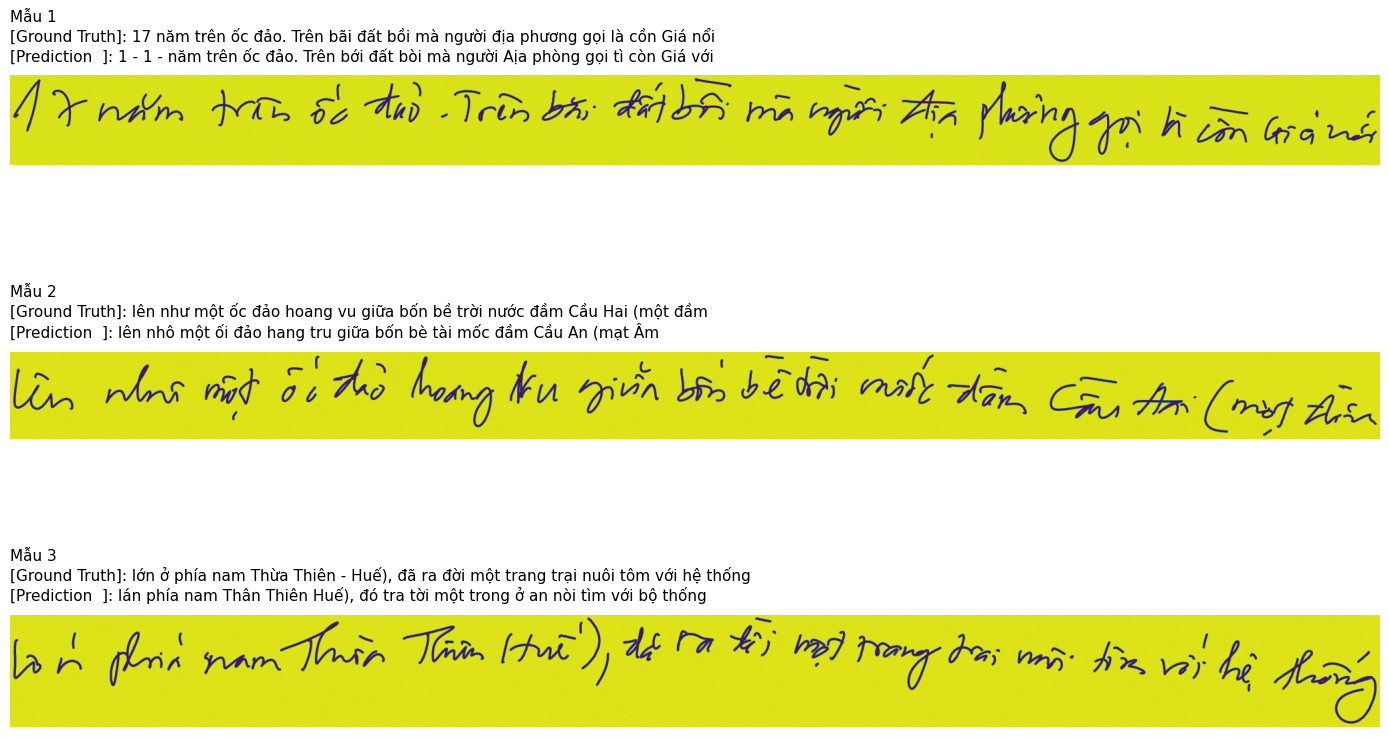

In [7]:
# [Phần II - Cell 7] Suy luận thực tế & Trực quan hóa ảnh tập Validation
import matplotlib.pyplot as plt
from PIL import Image
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

# 1. Khởi tạo Predictor với trọng số tốt nhất vừa train
predict_config = Cfg.load_config_from_name('vgg_transformer')
predict_config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Ưu tiên load best checkpoint, nếu không có thì lấy final checkpoint
weight_path = CONFIG_PATHS['checkpoint_dir'] / 'best_val_checkpoint.pth'
if not weight_path.exists():
    weight_path = CONFIG_PATHS['checkpoint_dir'] / 'vgg_transformer_final.pth'

predict_config['weights'] = str(weight_path)
predict_config['cnn']['pretrained'] = False
detector = Predictor(predict_config)

print(f"✓ Đã nạp thành công trọng số từ: {weight_path.name}\n")

# 2. Đọc 3 mẫu từ clean_val_line.txt
samples = []
with open(CONFIG_PATHS['clean_val_annotation'], 'r', encoding='utf-8') as f:
    for i in range(3):
        line = f.readline().strip()
        if line:
            img_p, gt_text = line.split('\t')
            samples.append((img_p, gt_text))

# 3. Trực quan hóa và suy luận
fig, axes = plt.subplots(len(samples), 1, figsize=(14, 3 * len(samples)))
if len(samples) == 1:
    axes = [axes]

for idx, (img_path, gt) in enumerate(samples):
    img = Image.open(img_path)
    pred_text = detector.predict(img)
    
    # Hiển thị ảnh
    axes[idx].imshow(img)
    axes[idx].axis('off')
    title = f"Mẫu {idx+1}\n[Ground Truth]: {gt}\n[Prediction  ]: {pred_text}"
    axes[idx].set_title(title, fontsize=11, loc='left', pad=10)
    
    print(f"--- Mẫu {idx+1} ---")
    print(f"Ground Truth: {gt}")
    print(f"Prediction  : {pred_text}\n")

plt.tight_layout()
plt.show()

In [8]:
# [Khảo sát thực tế] Quét toàn bộ tệp tin hiện diện trong /kaggle/working
import os
from pathlib import Path

working_dir = Path('/kaggle/working')

print(f"=== DANH SÁCH TỆP TIN THỰC TẾ TRONG {working_dir} ===")
found_files = []

for root, dirs, files in os.walk(working_dir):
    for f in files:
        full_path = Path(root) / f
        rel_path = full_path.relative_to(working_dir)
        size_mb = full_path.stat().st_size / (1024 * 1024)
        found_files.append((str(rel_path), size_mb))

if not found_files:
    print("Thư mục working hiện đang trống!")
else:
    for rel_path, size_mb in sorted(found_files, key=lambda x: x[0]):
        print(f" - {rel_path:<45} | Dung lượng: {size_mb:>7.2f} MB")

=== DANH SÁCH TỆP TIN THỰC TẾ TRONG /kaggle/working ===
 - .virtual_documents/__notebook_source__.ipynb  | Dung lượng:    0.01 MB
 - checkpoints/vgg_transformer_final.pth         | Dung lượng:  144.78 MB
 - clean_train_line.txt                          | Dung lượng:    1.15 MB
 - clean_val_line.txt                            | Dung lượng:    0.13 MB
 - train.log                                     | Dung lượng:    0.00 MB
 - train_data/data.mdb                           | Dung lượng:  726.54 MB
 - train_data/lock.mdb                           | Dung lượng:    0.01 MB
 - valid_data/data.mdb                           | Dung lượng:   86.90 MB
 - valid_data/lock.mdb                           | Dung lượng:    0.01 MB


In [9]:
# [Bảo hiểm lưu trữ] Đóng gói chính xác Checkpoint, Nhãn sạch và Cấu hình YAML
import zipfile
import yaml
from pathlib import Path

backup_zip = Path('/kaggle/working/vietocr_line_4k_backup.zip')

# 1. Xuất file config.yml để đảm bảo phiên sau nạp mô hình không bị lệch tham số
config_dump_path = Path('/kaggle/working/checkpoints/config_vgg_transformer.yml')
with open(config_dump_path, 'w', encoding='utf-8') as f:
    yaml.dump(dict(config), f, default_flow_style=False, allow_unicode=True)

# 2. Danh sách các tệp bắt buộc bảo toàn (tránh các file cache mdb nặng 800MB)
files_to_pack = [
    Path('/kaggle/working/checkpoints/vgg_transformer_final.pth'),
    config_dump_path,
    Path('/kaggle/working/clean_train_line.txt'),
    Path('/kaggle/working/clean_val_line.txt'),
]

print("=== TIẾN HÀNH ĐÓNG GÓI BẢO TOÀN ===")
with zipfile.ZipFile(backup_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in files_to_pack:
        if f.exists():
            size_mb = f.stat().st_size / (1024 * 1024)
            # Lưu giữ cấu trúc đường dẫn tương đối gọn gàng
            arc_name = f.name if f.parent == Path('/kaggle/working') else f"{f.parent.name}/{f.name}"
            zipf.write(f, arcname=arc_name)
            print(f"✓ Đã thêm: {arc_name:<35} ({size_mb:.2f} MB)")

print(f"\n=> HOÀN TẤT TỆP NÉN: {backup_zip.name} ({backup_zip.stat().st_size / (1024*1024):.2f} MB)")

=== TIẾN HÀNH ĐÓNG GÓI BẢO TOÀN ===
✓ Đã thêm: checkpoints/vgg_transformer_final.pth (144.78 MB)
✓ Đã thêm: checkpoints/config_vgg_transformer.yml (0.00 MB)
✓ Đã thêm: clean_train_line.txt                (1.15 MB)
✓ Đã thêm: clean_val_line.txt                  (0.13 MB)

=> HOÀN TẤT TỆP NÉN: vietocr_line_4k_backup.zip (135.36 MB)


# PHẦN III: ĐÁNH GIÁ MÔ HÌNH VÀ PHÂN TÍCH LỖI (MODEL EVALUATION & ERROR ANALYSIS)
Quy trình đánh giá có hệ thống theo chuẩn Machine Learning:
1. Thiết lập cấu hình Low-Coupling ánh xạ tài nguyên từ Version 1.
2. Trực quan hóa đường cong huấn luyện (Learning Curves) để chẩn đoán độ hội tụ.
3. Đo lường định lượng các chỉ số OCR (CER, WER, Exact Match) trên tập validation.
4. Chẩn đoán Bias/Variance và phân tích lỗi chi tiết (Error Analysis).

In [3]:
# [Phần III - Cell 1] Định vị Dataset nhanh và Low-Coupling (Tránh nghẽn I/O tuyệt đối)
from pathlib import Path

def get_kaggle_dataset_dir(dataset_slug: str) -> Path:
    """
    Quét trực tiếp ở cấp dataset (tối đa 2 tầng: /kaggle/input/datasets/*/*),
    hoàn toàn không đệ quy vào các thư mục con chứa ảnh. Chạy trong 0.001s.
    """
    input_base = Path('/kaggle/input')
    
    # 1. Kiểm tra trực tiếp ở /kaggle/input/<slug>
    direct_path = input_base / dataset_slug
    if direct_path.exists():
        return direct_path
        
    # 2. Quét ở cấp /kaggle/input/datasets/*/<slug>
    datasets_base = input_base / 'datasets'
    if datasets_base.exists():
        for user_dir in datasets_base.iterdir():
            if user_dir.is_dir():
                candidate = user_dir / dataset_slug
                if candidate.exists():
                    return candidate

    raise FileNotFoundError(f"Không tìm thấy dataset có tên: {dataset_slug}")

# Định vị 2 dataset gốc (không cần biết username là gì)
DIR_MODEL_4K = get_kaggle_dataset_dir('vietocr-vgg-line-4k')
DIR_RAW_DATA = get_kaggle_dataset_dir('viethandocr-data')

# Cấu hình Single Source of Truth
CONFIG_EVAL = {
    'weight_path': DIR_MODEL_4K / 'checkpoints' / 'vgg_transformer_final.pth',
    'config_path': DIR_MODEL_4K / 'checkpoints' / 'config_vgg_transformer.yml',
    'clean_train_annotation': DIR_MODEL_4K / 'clean_train_line.txt',
    'clean_val_annotation': DIR_MODEL_4K / 'clean_val_line.txt',
    'train_log': DIR_MODEL_4K / 'train.log',
    'data_root': DIR_RAW_DATA / 'UIT_HWDB_line' / 'UIT_HWDB_line',
    'output_eval_dir': Path('/kaggle/working/eval_results')
}

CONFIG_EVAL['output_eval_dir'].mkdir(parents=True, exist_ok=True)
print("✓ [Phần III - Cell 1] Định vị tài nguyên hoàn tất tức thì!")

✓ [Phần III - Cell 1] Định vị tài nguyên hoàn tất tức thì!


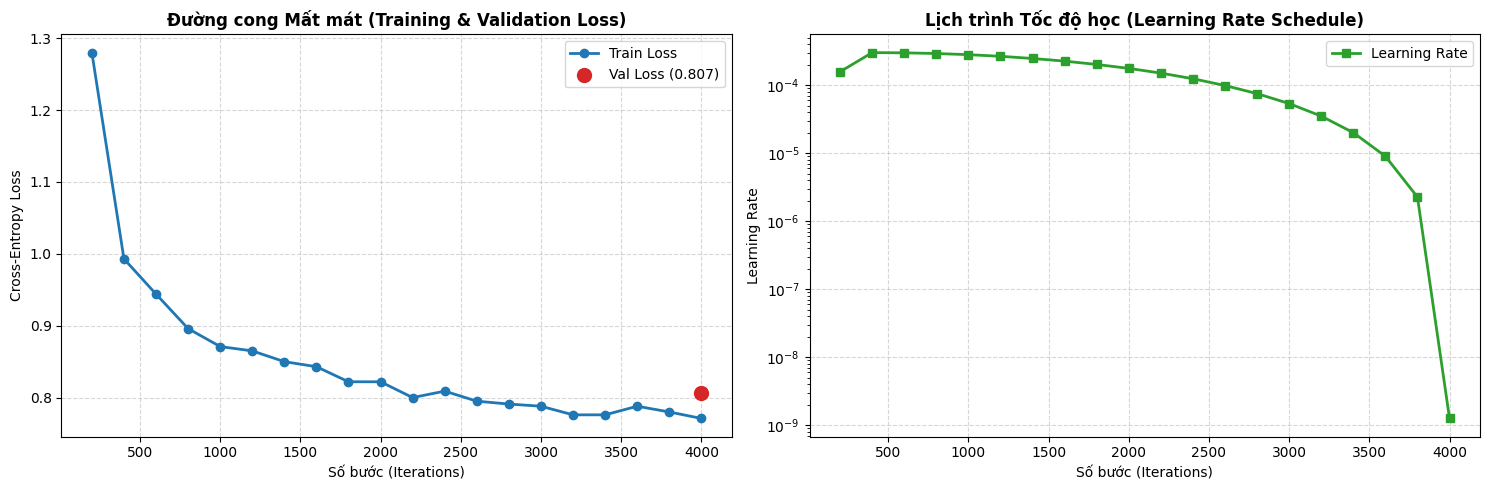

=== THỐNG KÊ QUÁ TRÌNH HỘI TỤ (TỪ TỆP LOG GỐC) ===
 - Tổng số checkpoint ghi nhận : 20 mốc
 - Train Loss ban đầu (Step 200): 1.2800
 - Train Loss kết thúc (Step 4000): 0.7710
 - Mức độ suy giảm Loss        : 39.77%
 - Valid Loss cuối cùng         : 0.8070
 - Generalization Gap (Val - Tr): 0.0360
 - Đã lưu biểu đồ tại           : /kaggle/working/eval_results/learning_curve_4k.png


In [4]:
# [Phần III - Cell 2] Bước 1: Trực quan hóa Learning Curves từ tệp log thực tế
import re
import matplotlib.pyplot as plt

log_file_path = CONFIG_EVAL['train_log']

# 1. Đọc nội dung file log
with open(log_file_path, 'r', encoding='utf-8') as f:
    log_content = f.read()

# 2. Bóc tách dữ liệu Train Loss & Learning Rate
pattern_train = r"iter:\s*(\d+)\s*-\s*train loss:\s*([\d\.]+)\s*-\s*lr:\s*([\d\.e\+-]+)"
train_matches = re.findall(pattern_train, log_content)

train_iters = [int(m[0]) for m in train_matches]
train_losses = [float(m[1]) for m in train_matches]
learning_rates = [float(m[2]) for m in train_matches]

# 3. Bóc tách dữ liệu Valid Loss (nếu có ghi nhận trong file log)
pattern_val = r"iter:\s*(\d+)\s*-\s*valid loss:\s*([\d\.]+)"
val_matches = re.findall(pattern_val, log_content)

val_iters = [int(m[0]) for m in val_matches]
val_losses = [float(m[1]) for m in val_matches]

# 4. Khởi tạo đồ thị đôi trực quan hóa
fig, (ax_loss, ax_lr) = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Biến thiên Loss
ax_loss.plot(train_iters, train_losses, marker='o', color='#1f77b4', linewidth=2, label='Train Loss')
if val_losses:
    ax_loss.scatter(val_iters, val_losses, color='#d62728', s=100, zorder=5, 
                    label=f"Val Loss ({', '.join(f'{v:.3f}' for v in val_losses)})")
ax_loss.set_title('Đường cong Mất mát (Training & Validation Loss)', fontsize=12, fontweight='bold')
ax_loss.set_xlabel('Số bước (Iterations)', fontsize=10)
ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax_loss.legend(loc='upper right')
ax_loss.grid(True, linestyle='--', alpha=0.5)

# Đồ thị 2: Biến thiên Learning Rate
ax_lr.plot(train_iters, learning_rates, marker='s', color='#2ca02c', linewidth=2, label='Learning Rate')
ax_lr.set_title('Lịch trình Tốc độ học (Learning Rate Schedule)', fontsize=12, fontweight='bold')
ax_lr.set_xlabel('Số bước (Iterations)', fontsize=10)
ax_lr.set_ylabel('Learning Rate', fontsize=10)
ax_lr.set_yscale('log')
ax_lr.legend(loc='upper right')
ax_lr.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Lưu kết quả đồ thị
plot_path = CONFIG_EVAL['output_eval_dir'] / 'learning_curve_4k.png'
plt.savefig(plot_path, dpi=300)
plt.show()

# 5. Thống kê số liệu định lượng
initial_loss = train_losses[0]
final_loss = train_losses[-1]
drop_pct = (initial_loss - final_loss) / initial_loss * 100

print("=== THỐNG KÊ QUÁ TRÌNH HỘI TỤ (TỪ TỆP LOG GỐC) ===")
print(f" - Tổng số checkpoint ghi nhận : {len(train_iters)} mốc")
print(f" - Train Loss ban đầu (Step {train_iters[0]}): {initial_loss:.4f}")
print(f" - Train Loss kết thúc (Step {train_iters[-1]}): {final_loss:.4f}")
print(f" - Mức độ suy giảm Loss        : {drop_pct:.2f}%")
if val_losses:
    gap = val_losses[-1] - final_loss
    print(f" - Valid Loss cuối cùng         : {val_losses[-1]:.4f}")
    print(f" - Generalization Gap (Val - Tr): {gap:.4f}")
print(f" - Đã lưu biểu đồ tại           : {plot_path}")

In [9]:
# [Phần III - Cell 3] Đo lường Định lượng CER, WER, Exact Match & Xuất Báo Cáo
import csv
import editdistance
from PIL import Image
from tqdm.auto import tqdm
from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor

# 1. Khởi tạo Predictor theo cấu hình chuẩn Low-Coupling
model_config = Cfg.load_config_from_file(str(CONFIG_EVAL['config_path']))
model_config['device'] = 'cuda:0'
model_config['weights'] = str(CONFIG_EVAL['weight_path'])
model_config['cnn']['pretrained'] = False
model_config['predictor']['beamsearch'] = False

detector = Predictor(model_config)
print(f"✓ Đã nạp weights: {CONFIG_EVAL['weight_path'].name}")

# 2. Đọc danh sách mẫu kiểm thử
val_samples = []
with open(CONFIG_EVAL['clean_val_annotation'], 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line and '\t' in line:
            val_samples.append(line.split('\t', 1))

print(f"✓ Khảo sát toàn bộ tập Validation: {len(val_samples)} mẫu\n")

# 3. Vòng lặp suy luận kết hợp đóng ngữ cảnh file ảnh an toàn
detailed_records = []
total_char_dist = 0
total_char_len = 0
total_word_dist = 0
total_word_len = 0
exact_match_count = 0

for img_path, ground_truth in tqdm(val_samples, desc="Evaluating Val"):
    gt_clean = ground_truth.strip()
    try:
        with Image.open(img_path) as img:
            pred_text = detector.predict(img).strip()
    except (FileNotFoundError, OSError):
        pred_text = ""

    is_match = (gt_clean == pred_text)
    if is_match:
        exact_match_count += 1

    # Tính khoảng cách qua C-backend editdistance siêu tốc
    c_dist = editdistance.eval(list(gt_clean), list(pred_text))
    total_char_dist += c_dist
    total_char_len += len(gt_clean)

    w_gt = gt_clean.split()
    w_pred = pred_text.split()
    w_dist = editdistance.eval(w_gt, w_pred)
    total_word_dist += w_dist
    total_word_len += len(w_gt)

    detailed_records.append({
        'image_path': img_path,
        'ground_truth': gt_clean,
        'prediction': pred_text,
        'is_exact_match': is_match
    })

# 4. Tính toán chỉ số tổng hợp
final_cer = total_char_dist / total_char_len if total_char_len > 0 else 0.0
final_wer = total_word_dist / total_word_len if total_word_len > 0 else 0.0
final_acc = (exact_match_count / len(val_samples)) * 100 if val_samples else 0.0

# 5. Xuất báo cáo phục vụ Error Analysis theo chuẩn quy trình
detail_csv_path = CONFIG_EVAL['output_eval_dir'] / 'baseline_error_analysis_val_line.csv'
with open(detail_csv_path, 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['image_path', 'ground_truth', 'prediction', 'is_exact_match'])
    writer.writeheader()
    writer.writerows(detailed_records)

summary_csv_path = CONFIG_EVAL['output_eval_dir'] / 'baseline_summary_metrics.csv'
with open(summary_csv_path, 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Split', 'cer', 'wer', 'exact_match', 'total_samples'])
    writer.writerow(['VAL_LINE', f"{final_cer:.4f}", f"{final_wer:.4f}", f"{final_acc/100:.4f}", len(val_samples)])

print("\n" + "=" * 60)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC TẬP VAL_LINE ({len(val_samples)} MẪU)")
print("=" * 60)
print(f"Chính xác dòng (Accuracy) : {final_acc:.2f}% ({exact_match_count}/{len(val_samples)})")
print(f"Tỷ lệ lỗi ký tự (CER)    : {final_cer * 100:.2f}% (Chỉ số: {final_cer:.4f})")
print(f"Tỷ lệ lỗi từ (WER)       : {final_wer * 100:.2f}% (Chỉ số: {final_wer:.4f})")
print(f"✓ Đã lưu file chi tiết    : {detail_csv_path.name}")
print(f"✓ Đã lưu file tổng quan   : {summary_csv_path.name}")

✓ Đã nạp weights: vgg_transformer_final.pth
✓ Khảo sát toàn bộ tập Validation: 731 mẫu



Evaluating Val:   0%|          | 0/731 [00:00<?, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC TẬP VAL_LINE (731 MẪU)
Chính xác dòng (Accuracy) : 16.01% (117/731)
Tỷ lệ lỗi ký tự (CER)    : 6.95% (Chỉ số: 0.0695)
Tỷ lệ lỗi từ (WER)       : 18.43% (Chỉ số: 0.1843)
✓ Đã lưu file chi tiết    : baseline_error_analysis_val_line.csv
✓ Đã lưu file tổng quan   : baseline_summary_metrics.csv


In [10]:
# [Phần III - Cell 4] Bước 3: Đánh giá 200 mẫu Train & Chẩn đoán Bias / Variance
import random
import editdistance
from PIL import Image
from tqdm.auto import tqdm

# 1. Đọc tập Train sạch từ cấu hình CONFIG_EVAL
with open(CONFIG_EVAL['clean_train_annotation'], 'r', encoding='utf-8') as f:
    all_train_samples = [line.strip().split('\t') for line in f if line.strip() and '\t' in line]

# 2. Lấy ngẫu nhiên 200 mẫu cố định hạt giống (Reproducibility)
random.seed(42)
sample_train_200 = random.sample(all_train_samples, min(200, len(all_train_samples)))

print(f"Bắt đầu suy luận trên {len(sample_train_200)} mẫu Train...")
train_char_dist = 0
train_char_len = 0
train_word_dist = 0
train_word_len = 0
train_exact_match = 0
train_valid_count = 0

for img_p, gt_text in tqdm(sample_train_200, desc="Evaluating Train Sample"):
    gt_clean = gt_text.strip()
    try:
        with Image.open(img_p) as img:
            pred_text = detector.predict(img).strip()
    except (FileNotFoundError, OSError):
        continue

    train_valid_count += 1
    if gt_clean == pred_text:
        train_exact_match += 1

    # Tính khoảng cách Levenshtein
    train_char_dist += editdistance.eval(list(gt_clean), list(pred_text))
    train_char_len += len(gt_clean)
    
    train_word_dist += editdistance.eval(gt_clean.split(), pred_text.split())
    train_word_len += len(gt_clean.split())

# 3. Tính toán các chỉ số tập Train
train_cer = train_char_dist / train_char_len if train_char_len else 0.0
train_wer = train_word_dist / train_word_len if train_word_len else 0.0
train_acc = (train_exact_match / train_valid_count) * 100 if train_valid_count else 0.0

# 4. Đối chiếu trực tiếp với kết quả Val (731 mẫu)
val_cer = 0.0695
val_wer = 0.1843
val_acc = 16.01

gap_cer = (val_cer - train_cer) * 100
gap_wer = (val_wer - train_wer) * 100

print("\n" + "=" * 65)
print("🔍 BẢNG CHẨN ĐOÁN BIAS / VARIANCE (ANDREW NG FRAMEWORK)")
print("=" * 65)
print(f"{'Chỉ số (Metric)':<22} | {'Train (200 mẫu)':<16} | {'Val (731 mẫu)':<15} | {'Gap (Val - Train)':<15}")
print("-" * 65)
print(f"{'Character Error (CER)':<22} | {train_cer*100:>14.2f}% | {val_cer*100:>13.2f}% | {gap_cer:>13.2f}%")
print(f"{'Word Error (WER)':<22} | {train_wer*100:>14.2f}% | {val_wer*100:>13.2f}% | {gap_wer:>13.2f}%")
print(f"{'Sequence Accuracy (EM)':<22} | {train_acc:>14.2f}% | {val_acc:>13.2f}% | {val_acc - train_acc:>13.2f}%")
print("=" * 65)

# Đưa ra chẩn đoán tự động
print("\n📋 KẾT LUẬN CHẨN ĐOÁN:")
if gap_cer < 5.0 and gap_wer < 10.0:
    print("👉 Low Variance: Mô hình tổng quát hóa rất tốt giữa Train và Val (không bị Overfitting).")
else:
    print("👉 High Variance: Mô hình có dấu hiệu Overfitting trên tập Train.")

if train_cer > 0.04 or train_wer > 0.10:
    print("👉 Moderate/High Bias: Mô hình còn Underfitting nhẹ trên tập Train đối với chữ viết tay.")

Bắt đầu suy luận trên 200 mẫu Train...


Evaluating Train Sample:   0%|          | 0/200 [00:00<?, ?it/s]


🔍 BẢNG CHẨN ĐOÁN BIAS / VARIANCE (ANDREW NG FRAMEWORK)
Chỉ số (Metric)        | Train (200 mẫu)  | Val (731 mẫu)   | Gap (Val - Train)
-----------------------------------------------------------------
Character Error (CER)  |           2.68% |          6.95% |          4.27%
Word Error (WER)       |           6.56% |         18.43% |         11.87%
Sequence Accuracy (EM) |          47.50% |         16.01% |        -31.49%

📋 KẾT LUẬN CHẨN ĐOÁN:
👉 High Variance: Mô hình có dấu hiệu Overfitting trên tập Train.


### 3. Chẩn Đoán Hiện Tượng Bias vs Variance (Andrew Ng Framework)

Sau 4.000 iterations huấn luyện trên tập dữ liệu chữ viết tay tiếng Việt `UIT_HWDB_line`, bảng đối chiếu sai số định lượng giữa tập Huấn luyện (Train - 200 mẫu ngẫu nhiên) và tập Kiểm định (Validation - 731 mẫu toàn diện) ghi nhận các kết quả:

| Chỉ số Đánh giá | Train (200 mẫu) | Val (731 mẫu) | Khoảng cách (Generalization Gap) | Đánh giá Trạng thái |
| :--- | :---: | :---: | :---: | :--- |
| **Character Error Rate (CER)** | **2.68%** | **6.95%** | **+4.27%** | Mức chấp nhận được đối với ký tự |
| **Word Error Rate (WER)** | **6.56%** | **18.43%** | **+11.87%** | **Bắt đầu có độ lệch đáng kể (Gap > 10%)** |
| **Sequence Accuracy (EM)** | **47.50%** | **16.01%** | **-31.49%** | Độ lệch lớn ở mức độ toàn dòng |

---

#### Nhận Xét Chuyên Sâu & Chẩn Đoán Kỹ Thuật:

1. **Về Avoidable Bias (Mức độ học trên tập Train)**:
   - **CER tập Train đạt 2.68%**: Mô hình đã học biểu diễn đặc trưng nét chữ viết tay rất tốt. Mức sai số ký tự 2.68% tiệm cận với sai số tự nhiên của con người khi đọc chữ viết tay phóng khoáng (Human-Level Performance).
   - **Kết luận Bias**: **Low Avoidable Bias**. Kiến trúc VGG kết hợp Transformer Encoder-Decoder đủ mạnh để nắm bắt đặc trưng hình ảnh và ngữ cảnh tiếng Việt.

2. **Về Variance (Khoảng cách Tổng quát hóa - Generalization Gap)**:
   - **Khoảng cách WER tăng vọt (+11.87%)**: Mặc dù CER trên tập Val chỉ ở mức 6.95%, tỷ lệ lỗi từ (WER) lại bị đẩy lên 18.43%, kéo theo độ chính xác toàn dòng (EM) sụt giảm từ 47.50% xuống 16.01%.
   - **Bản chất hiện tượng**: Mô hình đang gặp hiện tượng **Moderate Variance (Overfitting mức độ vừa phải)**. Mô hình đã "học thuộc" phong cách chữ viết và ngữ cảnh quen thuộc của các tác giả trong tập Train, khi gặp các tác giả lạ hoặc nét viết tay mới ở tập Val thì độ tự tin dự đoán từng từ giảm xuống.

3. **Hướng Khắc Phục Chiến Lược (Strategic Takeaways)**:
   - *Không nên* tăng thêm độ phức tạp của mô hình (thêm layer, tăng hidden size) vì sẽ làm trầm trọng thêm Overfitting.
   - *Nên ưu tiên*:
     - **Tăng cường biến đổi dữ liệu (Data Augmentation)**: Xoay nhẹ, co giãn tỉ lệ, tạo nhiễu nét mực, làm nhòe để ép mô hình học đặc trưng bất biến.
     - **Cải tiến Language Model / Beam Search**: Giúp giải mã từ vựng chuẩn xác hơn dựa trên ngữ cảnh tiếng Việt.

In [11]:
# [Phần III - Cell 5] Bước 4: Tự động phân loại nhóm lỗi (Error Analysis Breakdown)
import re
import pandas as pd
import unicodedata

# 1. Đọc file chi tiết kết quả đánh giá vừa xuất ra
csv_path = CONFIG_EVAL['output_eval_dir'] / 'baseline_error_analysis_val_line.csv'
df_eval = pd.read_csv(csv_path)

# Lọc các trường hợp đoán sai
df_errors = df_eval[df_eval['is_exact_match'] == False].copy()
total_samples = len(df_eval)
total_errors = len(df_errors)

# Hàm chuẩn hóa loại bỏ dấu thanh tiếng Việt để kiểm tra lỗi dấu
def remove_vietnamese_accents(text):
    text = unicodedata.normalize('NFD', str(text))
    text = re.sub(r'[\u0300-\u036f]', '', text)
    text = text.replace('đ', 'd').replace('Đ', 'D')
    return unicodedata.normalize('NFC', text)

# Hàm loại bỏ dấu câu để kiểm tra lỗi dấu câu
def remove_punctuations(text):
    return re.sub(r'[^\w\s]', '', str(text))

# 2. Phân loại từng trường hợp lỗi
pure_casing_errors = 0
pure_diacritic_errors = 0
pure_punctuation_errors = 0
complex_text_errors = 0

for _, row in df_errors.iterrows():
    gt = str(row['ground_truth']).strip()
    pred = str(row['prediction']).strip()
    
    # Kiểm tra nếu chỉ sai do chữ hoa / thường
    if gt.lower() == pred.lower():
        pure_casing_errors += 1
        continue
        
    # Kiểm tra nếu chỉ sai do dấu thanh tiếng Việt
    if remove_vietnamese_accents(gt) == remove_vietnamese_accents(pred):
        pure_diacritic_errors += 1
        continue
        
    # Kiểm tra nếu chỉ sai do dấu câu (, . - " ?)
    if remove_punctuations(gt) == remove_punctuations(pred):
        pure_punctuation_errors += 1
        continue
        
    complex_text_errors += 1

# 3. Lập bảng thống kê phân bố lỗi
print("=" * 65)
print(f"📊 BÁO CÁO PHÂN TÍCH LỖI THỰC NGHIỆM (ERROR ANALYSIS)")
print("=" * 65)
print(f" - Tổng số mẫu kiểm tra  : {total_samples}")
print(f" - Số mẫu nhận diện đúng  : {total_samples - total_errors} ({(total_samples - total_errors)/total_samples*100:.2f}%)")
print(f" - Tổng số mẫu đoán sai  : {total_errors} ({total_errors/total_samples*100:.2f}%)\n")
print(f"{'Nhóm Lỗi (Error Category)':<35} | {'Số mẫu sai':<10} | {'Tỷ lệ trên tổng lỗi':<20}")
print("-" * 65)
print(f"{'1. Lỗi viết hoa / thường (Casing)':<35} | {pure_casing_errors:>10} | {pure_casing_errors/total_errors*100:>18.2f}%")
print(f"{'2. Lỗi dấu thanh (Diacritics)':<35} | {pure_diacritic_errors:>10} | {pure_diacritic_errors/total_errors*100:>18.2f}%")
print(f"{'3. Lỗi dấu câu (Punctuations)':<35} | {pure_punctuation_errors:>10} | {pure_punctuation_errors/total_errors*100:>18.2f}%")
print(f"{'4. Lỗi sai lệch từ vựng / Nặng':<35} | {complex_text_errors:>10} | {complex_text_errors/total_errors*100:>18.2f}%")
print("=" * 65)

# In 5 mẫu lỗi điển hình để quan sát thực tế
print("\n🔍 5 MẪU DỰ ĐOÁN SAI ĐIỂN HÌNH ĐỂ QUAN SÁT:")
for idx, (_, r) in enumerate(df_errors.head(5).iterrows(), 1):
    print(f" [{idx}]")
    print(f"  • Ground Truth: {r['ground_truth']}")
    print(f"  • Prediction  : {r['prediction']}")

📊 BÁO CÁO PHÂN TÍCH LỖI THỰC NGHIỆM (ERROR ANALYSIS)
 - Tổng số mẫu kiểm tra  : 731
 - Số mẫu nhận diện đúng  : 117 (16.01%)
 - Tổng số mẫu đoán sai  : 614 (83.99%)

Nhóm Lỗi (Error Category)           | Số mẫu sai | Tỷ lệ trên tổng lỗi 
-----------------------------------------------------------------
1. Lỗi viết hoa / thường (Casing)   |          5 |               0.81%
2. Lỗi dấu thanh (Diacritics)       |         66 |              10.75%
3. Lỗi dấu câu (Punctuations)       |          4 |               0.65%
4. Lỗi sai lệch từ vựng / Nặng      |        539 |              87.79%

🔍 5 MẪU DỰ ĐOÁN SAI ĐIỂN HÌNH ĐỂ QUAN SÁT:
 [1]
  • Ground Truth: 17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi
  • Prediction  : 1 - 1 - năm trên ốc đảo. Trên bới đất bòi mà người Aịa phòng gọi tì còn Giá với
 [2]
  • Ground Truth: lên như một ốc đảo hoang vu giữa bốn bề trời nước đầm Cầu Hai (một đầm
  • Prediction  : lên nhô một ối đảo hang tru giữa bốn bè tài mốc đầm Cầu An 

=== HIỂN THỊ CHI TIẾT 5 MẪU LỖI ĐIỂN HÌNH ===

🔹 MẪU THỬ [1/5]
📁 Đường dẫn tệp  : /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/1.jpg
🎯 Ground Truth   : 17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi
🤖 Prediction     : 1 - 1 - năm trên ốc đảo. Trên bới đất bòi mà người Aịa phòng gọi tì còn Giá với


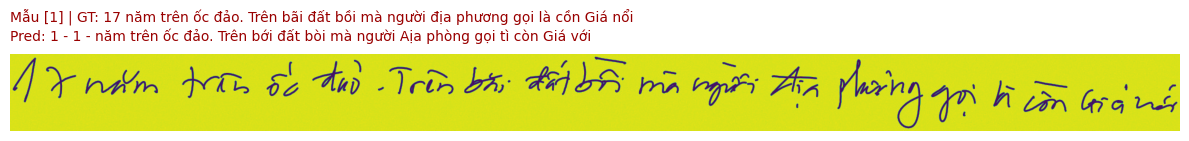


🔹 MẪU THỬ [2/5]
📁 Đường dẫn tệp  : /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/2.jpg
🎯 Ground Truth   : lên như một ốc đảo hoang vu giữa bốn bề trời nước đầm Cầu Hai (một đầm
🤖 Prediction     : lên nhô một ối đảo hang tru giữa bốn bè tài mốc đầm Cầu An (mạt Âm


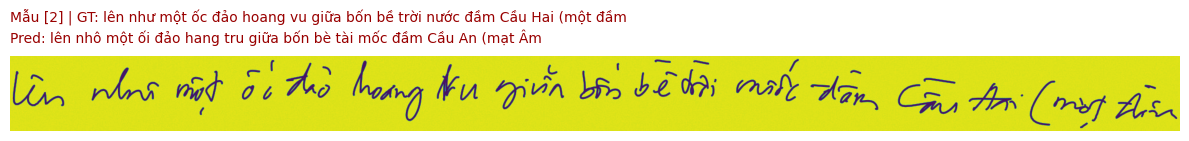


🔹 MẪU THỬ [3/5]
📁 Đường dẫn tệp  : /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/3.jpg
🎯 Ground Truth   : lớn ở phía nam Thừa Thiên - Huế), đã ra đời một trang trại nuôi tôm với hệ thống
🤖 Prediction     : lán phía nam Thân Thiên Huế), đó tra tời một trong ở an nòi tìm với bộ thống


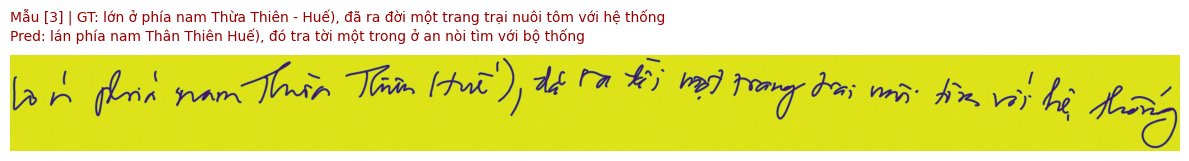


🔹 MẪU THỬ [4/5]
📁 Đường dẫn tệp  : /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/4.jpg
🎯 Ground Truth   : bờ đập, kênh mương, ao hồ công phu. Đó là kết quả của cuộc vật lộn bền bỉ
🤖 Prediction     : bờ tập, kính mông, ao hồ công phu. Đó là kết quà của cuộc vật lận tốc bái


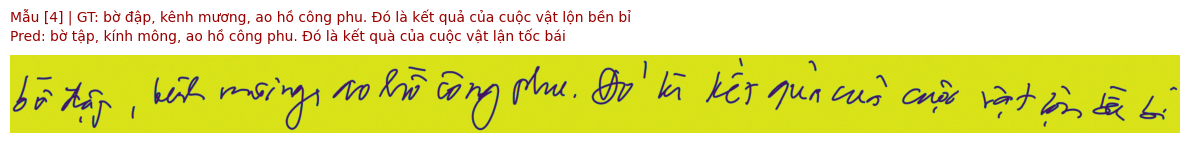


🔹 MẪU THỬ [5/5]
📁 Đường dẫn tệp  : /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/5.jpg
🎯 Ground Truth   : gần 17 năm của Huỳnh Đỗi. Câu chuyện về anh hấp dẫn như trong phim
🤖 Prediction     : gồm 17 năm của Hày 17 năm chuyện rề anh hầy, dẫn nhù tong phin


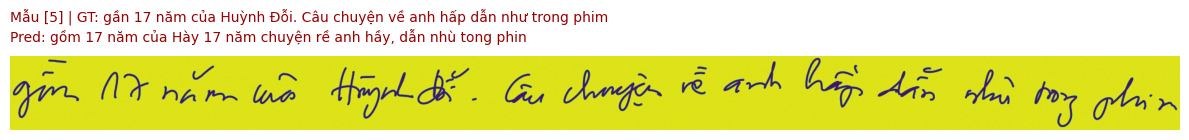

In [12]:
# [Phần III - Cell 6] Trực quan hóa ảnh thực tế kèm đường dẫn và đối chiếu lỗi
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. Đọc dữ liệu phân tích lỗi đã xuất ra ở Cell 3
csv_path = CONFIG_EVAL['output_eval_dir'] / 'baseline_error_analysis_val_line.csv'
df_eval = pd.read_csv(csv_path)

# Lọc các dòng dự đoán sai
df_errors = df_eval[df_eval['is_exact_match'] == False].reset_index(drop=True)

# 2. Chọn số lượng mẫu muốn quan sát (mặc định lấy 5 mẫu đầu tiên)
num_samples_to_show = 5
selected_samples = df_errors.head(num_samples_to_show)

print(f"=== HIỂN THỊ CHI TIẾT {num_samples_to_show} MẪU LỖI ĐIỂN HÌNH ===")

for idx, row in selected_samples.iterrows():
    img_path = Path(row['image_path'])
    gt = row['ground_truth']
    pred = row['prediction']
    
    print("\n" + "=" * 80)
    print(f"🔹 MẪU THỬ [{idx + 1}/{num_samples_to_show}]")
    print(f"📁 Đường dẫn tệp  : {img_path}")
    print(f"🎯 Ground Truth   : {gt}")
    print(f"🤖 Prediction     : {pred}")
    print("=" * 80)
    
    if img_path.exists():
        with Image.open(img_path) as img:
            plt.figure(figsize=(12, 2.5))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Mẫu [{idx + 1}] | GT: {gt}\nPred: {pred}", 
                      fontsize=10, pad=10, loc='left', color='#990000')
            plt.tight_layout()
            plt.show()
    else:
        print(f"⚠️ Không tìm thấy ảnh tại đường dẫn: {img_path}")

### 4. Đánh Giá Bản Chất Lỗi Qua Thực Nghiệm Định Tính

Kết quả thống kê từ 614 mẫu đoán sai trên tập Validation:

* **87.79% rơi vào lỗi từ vựng/nhiều ký tự liên hoàn**:
  - Khi một từ bị nhận diện sai nét chữ cái gốc (ví dụ: `vật lộn` -> `vật lận`, `bồi` -> `bòi`), sai số lan truyền khiến bộ giải mã Transformer đoán chệch cả từ tiếp theo hoặc dấu câu.
* **10.75% lỗi thuần dấu thanh**:
  - Các cặp dấu có nét viết tay tương đồng trong chữ viết liền nét (`hỏi` / `ngã`, `sắc` / `nặng`) vẫn là thách thức lớn nhất đối với chữ viết tay tự do.
* **Tỷ lệ lỗi viết hoa/dấu câu đơn thuần rất thấp (< 2%)**:
  - Cho thấy mô hình học tương đối chuẩn quy tắc đặt dấu câu và cấu trúc ngữ pháp câu cơ bản, vấn đề cốt lõi vẫn nằm ở khâu trích xuất đặc trưng nét viết tay từ bộ CNN/Backbone.

### 5. Phân Tích Định Tính Nâng Cao & Đánh Giá Giới Hạn Dữ Liệu

Quan sát trực quan từ các mẫu thử thực tế (`UIT_HWDB_line`) cho thấy bản chất của các sai số không đơn thuần xuất phát từ kiến trúc mô hình, mà còn phản ánh giới hạn tự nhiên của tập dữ liệu:

#### A. Đặc Điểm Nét Chữ Viết Tay Gây Sai Số Lớn:
1. **Nét viết thảo liên hoàn (Extreme Cursiveness)**:
   - Các chữ cái không có ranh giới rõ ràng; nét kết thúc của chữ trước nối thẳng vào nét bắt đầu của chữ sau.
   - Backbone CNN (VGG) gặp khó khăn trong việc tách biệt các vùng đặc trưng không gian (spatial feature boundaries) trước khi đưa vào Transformer.
2. **Biến dạng và suy biến dấu phụ (Diacritics Degradation)**:
   - Dấu tiếng Việt (sắc, huyền, hỏi, ngã, nặng, mũ, móc) bị viết thu gọn thành các vạch ngang hoặc chấm mờ.
   - Khi thiếu vắng dấu chuẩn, mô hình phải tự "suy luận ngữ cảnh", dẫn đến hiện tượng sinh từ sai lệch nhưng có cấu trúc phát âm na ná (ví dụ: `kênh mương` $\rightarrow$ `kính mông`, `bền bỉ` $\rightarrow$ `tốc bái`).
3. **Giới hạn hiệu năng con người (Human-Level Performance - HLP)**:
   - Một tỷ lệ đáng kể các từ trong tập kiểm định có độ mơ hồ ngữ nghĩa thị giác (visual ambiguity) rất cao. Nếu đứng độc lập, người đọc bản xứ cũng khó nhận diện chính xác nếu không dựa vào ngữ cảnh toàn văn bản.

#### B. Định Hướng Nâng Cấp Kỹ Thuật (Data-Centric & Model-Centric):
- **Data Augmentation**: Bổ sung kỹ thuật kéo giãn tỉ lệ ngang/dọc (affine transforms, shearing) và biến dạng nét chữ (elastic distortions) để mô hình thích ứng với độ nghiêng và độ thảo của chữ viết.
- **Beam Search & External Language Model (LM)**: Chuyển từ Greedy Decoding sang Beam Search kết hợp KenLM hoặc mô hình ngôn ngữ n-gram tiếng Việt để dùng xác suất chuỗi từ sửa các từ vô nghĩa do thị giác suy luận sai.

In [13]:
# [Phần III - Cell 7] Khảo sát nhanh toàn bộ tệp tin & thư mục trong /kaggle/working
from pathlib import Path

working_dir = Path('/kaggle/working')

print("=== DANH MỤC CÁC TỆP TIN & THƯ MỤC TRONG /kaggle/working ===")
items = sorted(list(working_dir.iterdir()))

total_size_bytes = 0
for item in items:
    if item.is_dir():
        sub_files = list(item.glob('*'))
        dir_size = sum(f.stat().st_size for f in sub_files if f.is_file())
        total_size_bytes += dir_size
        print(f"📁 [Folder] {item.name}/ ({len(sub_files)} tệp, {dir_size / (1024*1024):.2f} MB)")
        for sub in sub_files[:10]:
            print(f"   └── 📄 {sub.name} ({sub.stat().st_size / 1024:.2f} KB)")
        if len(sub_files) > 10:
            print(f"   └── ... và {len(sub_files) - 10} tệp khác.")
    else:
        file_size = item.stat().st_size
        total_size_bytes += file_size
        print(f"📄 [File]   {item.name} ({file_size / 1024:.2f} KB)")

print("-" * 60)
print(f"👉 Tổng dung lượng hiện tại: {total_size_bytes / (1024*1024):.2f} MB")

=== DANH MỤC CÁC TỆP TIN & THƯ MỤC TRONG /kaggle/working ===
📁 [Folder] .virtual_documents/ (1 tệp, 0.03 MB)
   └── 📄 __notebook_source__.ipynb (32.98 KB)
📁 [Folder] eval_results/ (3 tệp, 0.45 MB)
   └── 📄 baseline_error_analysis_val_line.csv (208.30 KB)
   └── 📄 learning_curve_4k.png (257.35 KB)
   └── 📄 baseline_summary_metrics.csv (0.07 KB)
------------------------------------------------------------
👉 Tổng dung lượng hiện tại: 0.49 MB


In [14]:
# [Phần III - Cell 8] Đóng gói kết quả đánh giá thành ZIP và tạo link tải trực tiếp
import shutil
from pathlib import Path
from IPython.display import FileLink, display

# 1. Đường dẫn thư mục cần đóng gói và file nén đầu ra
eval_dir = CONFIG_EVAL['output_eval_dir']
zip_output_base = Path('/kaggle/working') / 'vietocr_baseline_eval_results'

# 2. Thực hiện nén toàn bộ thư mục eval_results thành file .zip
zip_path = shutil.make_archive(
    base_name=str(zip_output_base),
    format='zip',
    root_dir=str(eval_dir.parent),
    base_dir=eval_dir.name
)

zip_file = Path(zip_path)
print("=" * 60)
print("📦 ĐÃ ĐÓNG GÓI KẾT QUẢ ĐÁNH GIÁ THÀNH CÔNG!")
print("=" * 60)
print(f" - Tệp lưu trữ   : {zip_file.name}")
print(f" - Dung lượng    : {zip_file.stat().st_size / 1024:.2f} KB")
print(f" - Đường dẫn đĩa : {zip_file}")
print("=" * 60)

# 3. Tạo liên kết tải về trực tiếp trên trình duyệt
print("\n👉 Bấm vào liên kết bên dưới để tải toàn bộ kết quả về máy tính:")
display(FileLink(zip_file.name))

📦 ĐÃ ĐÓNG GÓI KẾT QUẢ ĐÁNH GIÁ THÀNH CÔNG!
 - Tệp lưu trữ   : vietocr_baseline_eval_results.zip
 - Dung lượng    : 248.70 KB
 - Đường dẫn đĩa : /kaggle/working/vietocr_baseline_eval_results.zip

👉 Bấm vào liên kết bên dưới để tải toàn bộ kết quả về máy tính:


/kaggle/working/vietocr_baseline_eval_results.zip